# 01 - Exploration des donnees

**Auteur :** Gregory CRESPIN | **Date :** 30/01/2026 | **Version :** 1.0

---

DESCRIPTIF : Ce notebook est la premiere etape du projet. On explore les donnees
brutes pour comprendre leur structure, identifier les valeurs manquantes,
analyser la distribution de la variable cible (TARGET) et les relations
entre variables. Cette exploration guide les etapes suivantes.

In [1]:
# Importation des bibliothèques nécessaires pour l'exploration des données
import pandas as pd  # pandas : pour manipuler les tableaux de données (DataFrames)
import numpy as np  # numpy : pour les calculs numériques
import matplotlib.pyplot as plt  # matplotlib : pour créer des graphiques
import seaborn as sns  # seaborn : bibliothèque de visualisation statistique (plus jolie que matplotlib)
import missingno as msno  # missingno : bibliothèque spécialisée pour visualiser les valeurs manquantes
import warnings  # warnings : pour gérer les avertissements Python
# Ignorer tous les avertissements pour avoir une sortie plus propre
warnings.filterwarnings('ignore')

# Configuration des graphiques
# Définir le style des graphiques matplotlib (style seaborn moderne)
plt.style.use('seaborn-v0_8')
# Définir la palette de couleurs pour seaborn (palette "husl" = dégradé de couleurs)
sns.set_palette("husl")
# %matplotlib inline : commande magique Jupyter pour afficher les graphiques directement dans le notebook
%matplotlib inline

In [2]:
# Charger les données du projet
# sys : module système Python pour manipuler le chemin de recherche des modules
import sys
# Ajouter le répertoire parent au chemin Python pour pouvoir importer nos modules personnalisés
# '..' signifie le répertoire parent (un niveau au-dessus du dossier notebooks/)
sys.path.append('..')
# Importer la fonction load_data depuis notre module data_loader
from src.data_loader import load_data

# Charger tous les fichiers CSV du projet
# load_data() parcourt le dossier '../data' et charge chaque fichier CSV
# Retourne un dictionnaire {nom_fichier: DataFrame}
data_dict = load_data('../data')

Chargement de application_train.csv...
  Shape: (307511, 122)
Chargement de application_test.csv...
  Shape: (48744, 121)
Chargement de bureau.csv...
  Shape: (1716428, 17)
Chargement de bureau_balance.csv...
  Shape: (27299925, 3)
Chargement de previous_application.csv...
  Shape: (1670214, 37)
Chargement de POS_CASH_balance.csv...
  Shape: (10001358, 8)
Chargement de credit_card_balance.csv...
  Shape: (3840312, 23)
Chargement de installments_payments.csv...
  Shape: (13605401, 8)
Chargement de HomeCredit_columns_description.csv...
  Shape: (219, 5)


## 1. Exploration de la table principale (application_train)

In [3]:
df_train = data_dict['application_train']
print(f"Shape: {df_train.shape}")
print(f"\nColonnes: {len(df_train.columns)}")
df_train.head()

Shape: (307511, 122)

Colonnes: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Informations générales
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## 2. Analyse des doublons

DESCRIPTIF : Avant de fusionner les tables, il est important de verifier l'absence
de doublons. Des lignes dupliquees ou des identifiants en double peuvent fausser
les resultats (ex: un meme client compte plusieurs fois). On verifie :
- Les lignes entierement dupliquees
- Les doublons sur l'identifiant client (SK_ID_CURR) dans les tables principales
- Les chevauchements entre train et test

In [5]:
# Analyse des doublons dans application_train
print("=== APPLICATION_TRAIN ===\n")

# Lignes entierement dupliquees
n_dup_rows = df_train.duplicated().sum()
print(f"Lignes entierement dupliquees: {n_dup_rows}")

# Doublons sur l'identifiant client (chaque client doit apparaitre 1 seule fois)
if 'SK_ID_CURR' in df_train.columns:
    n_dup_ids = df_train['SK_ID_CURR'].duplicated().sum()
    n_unique_ids = df_train['SK_ID_CURR'].nunique()
    print(f"Doublons sur SK_ID_CURR: {n_dup_ids}")
    print(f"Nombre de clients uniques: {n_unique_ids}")
    print(f"Nombre total de lignes: {len(df_train)}")
    if n_dup_ids > 0:
        dup_ids = df_train[df_train['SK_ID_CURR'].duplicated(keep=False)]['SK_ID_CURR'].unique()
        print(f"Exemple d'IDs en double: {dup_ids[:5].tolist()}")

# Meme analyse pour application_test
print("\n=== APPLICATION_TEST ===\n")
df_test = data_dict['application_test']
n_dup_rows_test = df_test.duplicated().sum()
print(f"Lignes entierement dupliquees: {n_dup_rows_test}")
if 'SK_ID_CURR' in df_test.columns:
    n_dup_ids_test = df_test['SK_ID_CURR'].duplicated().sum()
    print(f"Doublons sur SK_ID_CURR: {n_dup_ids_test}")
    print(f"Nombre de clients uniques: {df_test['SK_ID_CURR'].nunique()}")

# Chevauchement train/test : des clients du test sont-ils dans le train ?
print("\n=== CHEVAUCHEMENT TRAIN/TEST ===\n")
train_ids = set(df_train['SK_ID_CURR'])
test_ids = set(df_test['SK_ID_CURR'])
overlap = train_ids & test_ids
print(f"Clients presents dans train ET test: {len(overlap)}")
if len(overlap) > 0:
    print("[ATTENTION] Des clients du test apparaissent dans le train - risque de fuite de donnees !")

# Doublons dans les tables annexes (bureau : 1 client peut avoir plusieurs credits)
print("\n=== TABLES ANNEXES ===\n")
if 'bureau' in data_dict:
    df_bureau = data_dict['bureau']
    n_bureau = len(df_bureau)
    n_unique_bureau = df_bureau['SK_ID_CURR'].nunique()
    print(f"Bureau: {n_bureau} lignes, {n_unique_bureau} clients uniques (1 client = plusieurs credits attendu)")

=== APPLICATION_TRAIN ===

Lignes entierement dupliquees: 0
Doublons sur SK_ID_CURR: 0
Nombre de clients uniques: 307511
Nombre total de lignes: 307511

=== APPLICATION_TEST ===

Lignes entierement dupliquees: 0
Doublons sur SK_ID_CURR: 0
Nombre de clients uniques: 48744

=== CHEVAUCHEMENT TRAIN/TEST ===

Clients presents dans train ET test: 0

=== TABLES ANNEXES ===

Bureau: 1716428 lignes, 305811 clients uniques (1 client = plusieurs credits attendu)


In [6]:
# Statistiques descriptives
df_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


## 3. Analyse de la variable cible

TARGET
0    282686
1     24825
Name: count, dtype: int64

Pourcentage de classe 1 (mauvais client): 8.07%


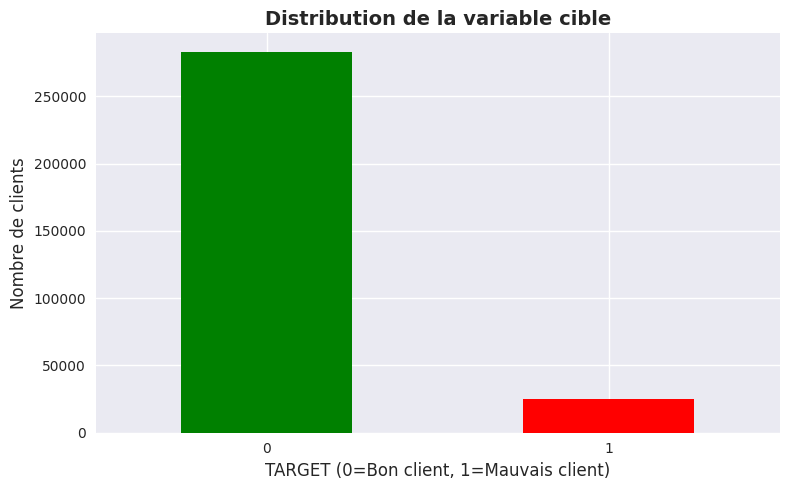

In [7]:
# Distribution de la variable cible
target_col = 'TARGET'
if target_col in df_train.columns:
    target_dist = df_train[target_col].value_counts()
    print(target_dist)
    print(f"\nPourcentage de classe 1 (mauvais client): {target_dist[1] / len(df_train) * 100:.2f}%")
    
    # Visualisation
    plt.figure(figsize=(8, 5))
    target_dist.plot(kind='bar', color=['green', 'red'])
    plt.title('Distribution de la variable cible', fontsize=14, fontweight='bold')
    plt.xlabel('TARGET (0=Bon client, 1=Mauvais client)', fontsize=12)
    plt.ylabel('Nombre de clients', fontsize=12)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 4. Analyse des valeurs manquantes

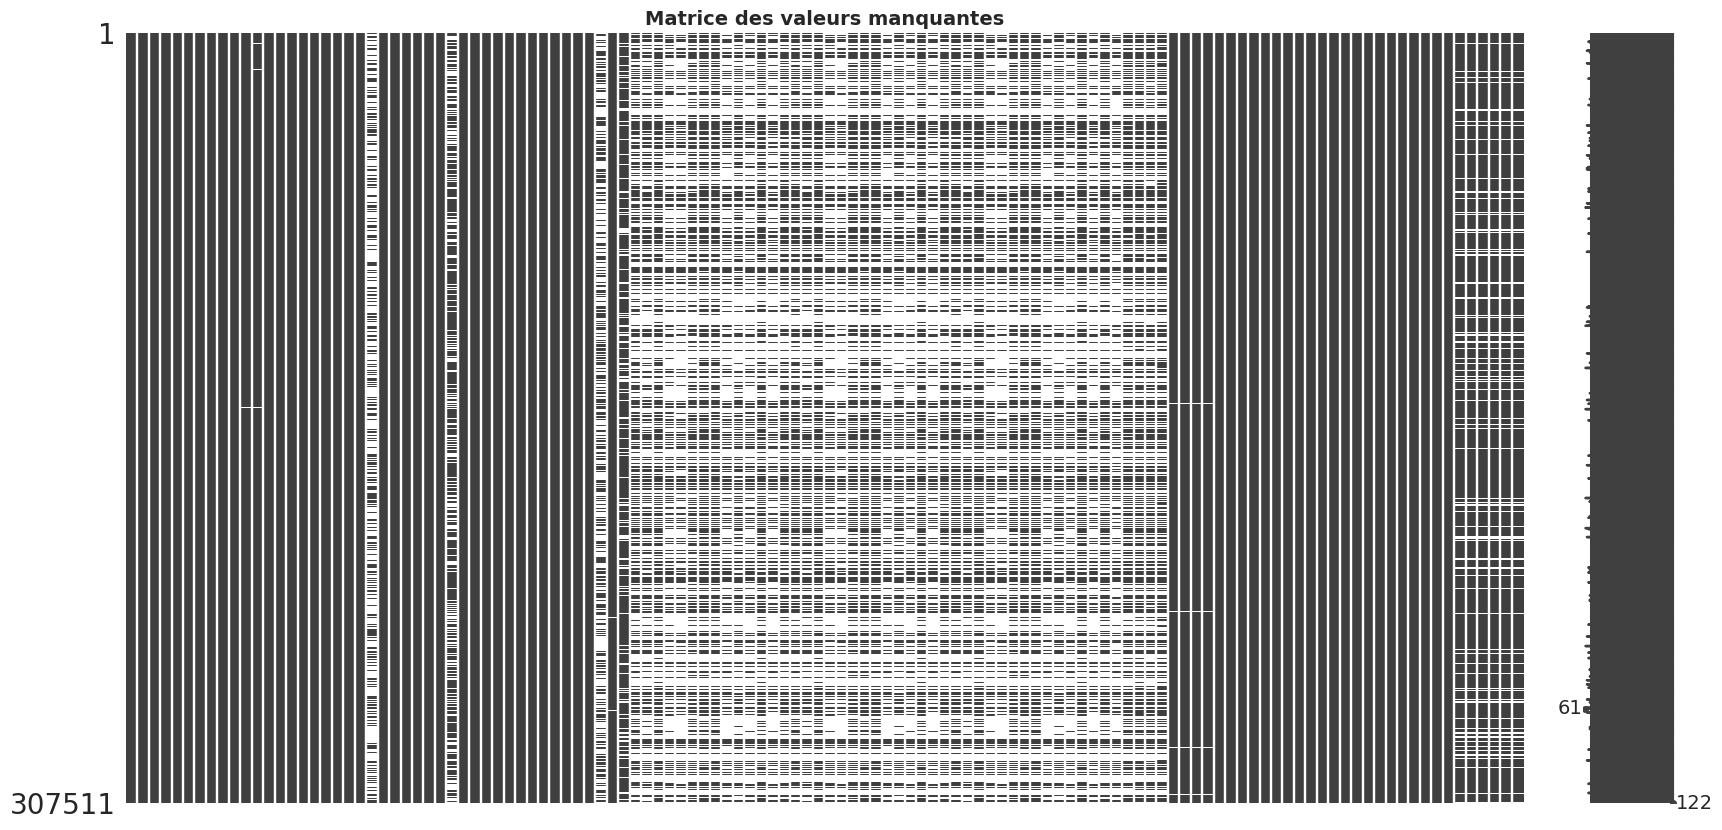

In [8]:
# Matrice des valeurs manquantes
msno.matrix(df_train, figsize=(20, 10))
plt.title('Matrice des valeurs manquantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Nombre de colonnes avec valeurs manquantes: 67

Top 20 colonnes avec le plus de valeurs manquantes:
COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64


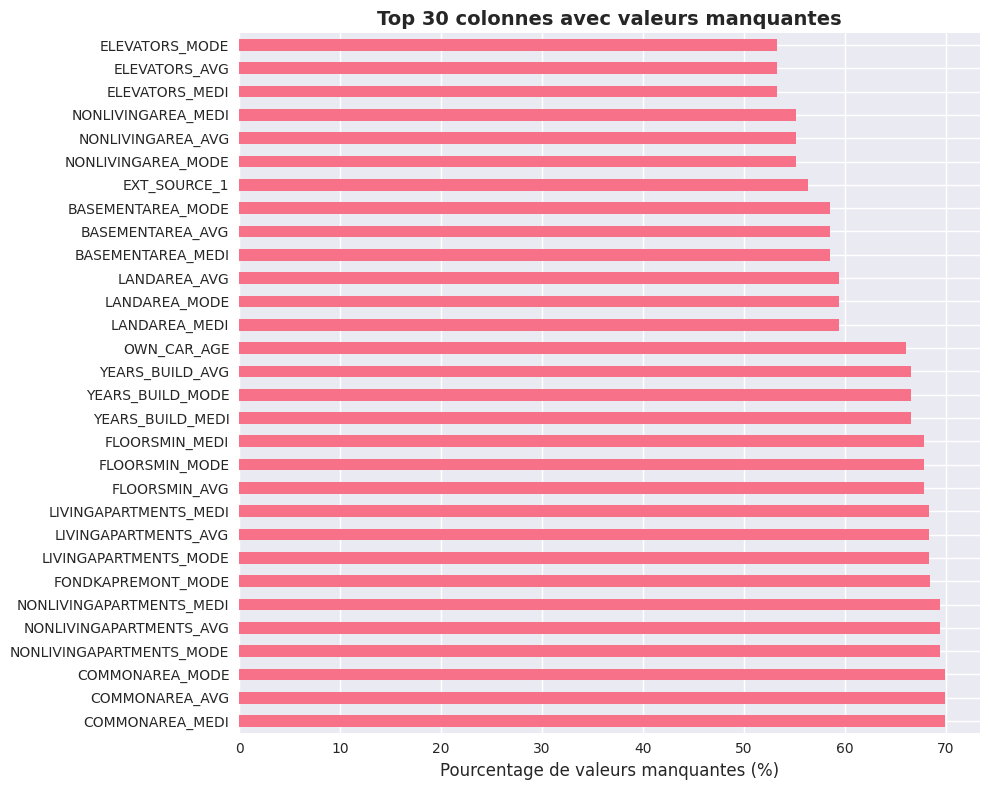

In [9]:
# Pourcentage de valeurs manquantes par colonne
missing_percent = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_percent = missing_percent[missing_percent > 0]

print(f"Nombre de colonnes avec valeurs manquantes: {len(missing_percent)}")
print(f"\nTop 20 colonnes avec le plus de valeurs manquantes:")
print(missing_percent.head(20))

# Visualisation
plt.figure(figsize=(10, 8))
missing_percent.head(30).plot(kind='barh')
plt.title('Top 30 colonnes avec valeurs manquantes', fontsize=14, fontweight='bold')
plt.xlabel('Pourcentage de valeurs manquantes (%)', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Exploration des autres tables

In [10]:
# Aperçu de toutes les tables
for name, df in data_dict.items():
    if name != 'HomeCredit_columns_description':
        print(f"\n{'='*50}")
        print(f"Table: {name}")
        print(f"Shape: {df.shape}")
        print(f"Colonnes: {list(df.columns[:10])}..." if len(df.columns) > 10 else f"Colonnes: {list(df.columns)}")
        print(f"Valeurs manquantes: {df.isnull().sum().sum()}")


Table: application_train
Shape: (307511, 122)
Colonnes: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']...
Valeurs manquantes: 9152465

Table: application_test
Shape: (48744, 121)
Colonnes: ['SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']...
Valeurs manquantes: 1404419

Table: bureau
Shape: (1716428, 17)
Colonnes: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG']...
Valeurs manquantes: 3939947

Table: bureau_balance
Shape: (27299925, 3)
Colonnes: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']
Valeurs manquantes: 0

Table: previous_application
Shape: (1670214, 37)
Colonnes: ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONT

## 6. Analyse des relations entre variables cles

Corrélations avec la variable cible:
TARGET              1.000000
AMT_INCOME_TOTAL   -0.003982
AMT_ANNUITY        -0.012817
AMT_CREDIT         -0.030369
AMT_GOODS_PRICE    -0.039645
Name: TARGET, dtype: float64


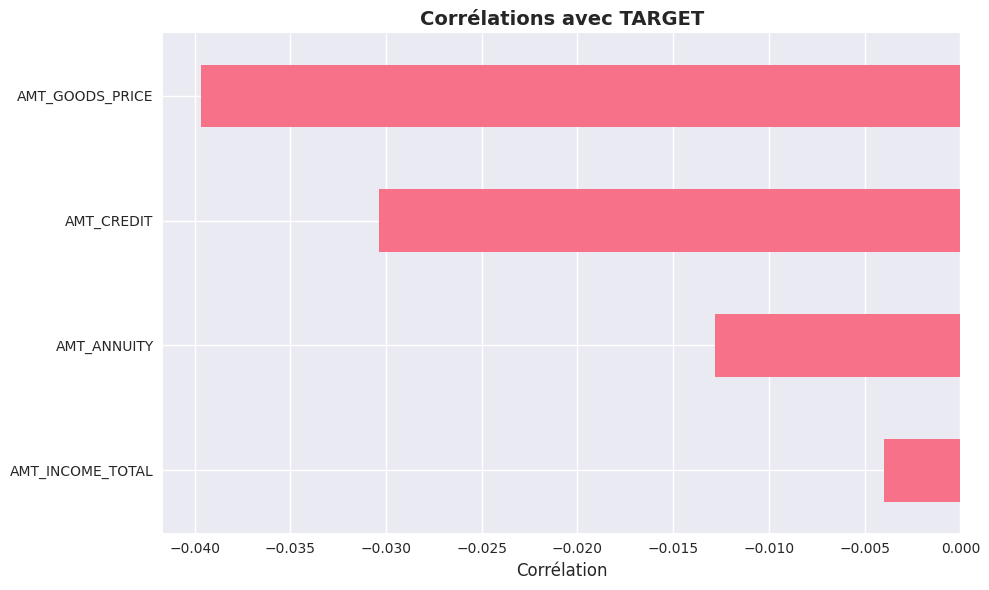

In [12]:
# Sélection de quelques variables numériques importantes
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
key_vars = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
available_vars = [v for v in key_vars if v in numeric_cols]

if available_vars and target_col in df_train.columns:
    # Corrélations avec la variable cible
    correlations = df_train[available_vars + [target_col]].corr()[target_col].sort_values(ascending=False)
    print("Corrélations avec la variable cible:")
    print(correlations)
    
    # Visualisation
    plt.figure(figsize=(10, 6))
    correlations.drop(target_col).plot(kind='barh')
    plt.title('Corrélations avec TARGET', fontsize=14, fontweight='bold')
    plt.xlabel('Corrélation', fontsize=12)
    plt.tight_layout()
    plt.show()

## 7. Conclusions de l'exploration

### Vue d'ensemble des données

Le jeu de données est composé de **8 tables** reliées entre elles par des identifiants (SK_ID_CURR pour les clients, SK_ID_BUREAU et SK_ID_PREV pour les crédits). La table principale **application_train** contient **307 511 clients** avec **122 variables** décrivant chaque demande de crédit.

### Valeurs manquantes

- **67 colonnes** contiennent des valeurs manquantes dans la table principale.
- Les colonnes les plus impactées concernent surtout les **caractéristiques du logement** (COMMONAREA, LIVINGAPARTMENTS, FLOORSMIN, YEARS_BUILD, LANDAREA) et **OWN_CAR_AGE** (âge du véhicule) — entre 60 % et 70 % de valeurs manquantes.
- **Recommandation** : plutôt que de supprimer ces colonnes, envisager une **imputation** (remplacer les manquants par la médiane ou une valeur par défaut) ou créer une variable indiquant la présence/absence d'information.

### Déséquilibre des classes (variable cible TARGET)

- La variable **TARGET** indique si le client a eu des difficultés de remboursement (1 = oui, 0 = non).
- Le nombre de **bons clients (0)** est nettement supérieur au nombre de **mauvais clients (1)**.
- **Conclusion pour la suite** : utiliser des techniques adaptees au desequilibre : class_weight='balanced', SMOTE, ou metriques comme l'AUC-PR (plus adaptee que l'AUC-ROC pour ~8% de classe positive), Precision et Recall au seuil optimal.

### Structure des tables annexes

- **bureau** : historique des crédits auprès d'autres institutions (~1,7 M lignes).
- **bureau_balance** : historique mensuel des crédits bureau (~27 M lignes).
- **previous_application** : demandes précédentes chez Home Credit (~1,7 M lignes).
- **POS_CASH_balance**, **credit_card_balance**, **installments_payments** : historique des remboursements et des cartes de crédit.

Ces tables sont volumineuses et contiennent des valeurs manquantes. Elles seront agrégées par client avant fusion avec la table principale.

### Corrélations avec la variable cible

Les variables financières testées (AMT_INCOME_TOTAL, AMT_ANNUITY, AMT_CREDIT, AMT_GOODS_PRICE) ont des **corrélations très faibles** avec TARGET (entre -0,004 et -0,04). Cela suggère que :

- Ces variables seules ne suffisent pas à prédire le défaut.
- Il faudra exploiter les **tables annexes** (bureau, previous_application, etc.) et créer des **features agrégées** pour améliorer le modèle.

### Prochaines étapes

1. **Préparation des données** : fusionner les tables, imputer les valeurs manquantes, encoder les variables catégorielles.
2. **Feature engineering** : créer des variables agrégées à partir des tables bureau, previous_application, etc.
3. **Modélisation** : tester plusieurs algorithmes en gérant le déséquilibre des classes et en utilisant la validation croisée.